# VQE Workshop notebook

#### Prerequisites:
- Familiarity with qubits, quantum gates, and quantum circuits at the level of standard introductory material (Nielsen & Chuang Ch. 1–4 or equivalent recommended).
- Comfort with Python and NumPy. PennyLane syntax is introduced as it is used.
- No prior knowledge of quantum chemistry or variational methods is assumed.

#### Software
This notebook uses **PennyLane** (version ≥ 0.39). Run the following cells to verify your environment before proceeding.

In [2]:
pip install --upgrade pip

  Using cached pip-26.1.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import subprocess
import importlib

import pennylane as qml
from pennylane import numpy as np   # PennyLane's NumPy wrapper (supports autograd)
import numpy as _np                  # Standard NumPy for non-differentiable ops
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)



#### Real-world applications of interest:
- Quantum Chemistry - nitrogen fixation, drug-binding and protein-folding
- Condensed matter - high temp superconductivity
- Nuclear physics - nuclear binding energies
-


#### VQAs

#### Looking at VQE

In this notebook, we will take a closer look at the Variational Quantum Eigensolver algorithm, commonly abbreviated as VQE, to see how it approaches solving the problems discussed above. We begin by building a small Hamiltonian example for the hydrogen (**H₂**) molecule and solve it through exact diagonalisation to establish a classical baseline reference. After that, the same problem is approached through VQE using a parametrised quantum circuit, expectation value estimation, and performing classical optimisation. The final sections discuss some limitations, other implementations, next steps, challenge questions, and open-ended research directions.


In [ ]:
# write interactive protein folding visualisation



There is one common feature among all of the applications described above: at some approximation level, each of them reduces to the same mathematical problem - finding the lowest eigenvalue and corresponding eigenstate of a quantum many-body Hamiltonian, which may be described in second quantisation.

In quantum chemistry, we express our molecular Hamiltonian by mapping spin operators onto a sum of creation and annihilation operators acting on fermionic modes, and in order to simulate the molecule we map these fermionic representations onto qubit operators. We obtain the qubit Hamiltonian using Pennylane which uses the Jordan-Wigner Transformation. The final Hamiltonian is a linear combination of Pauli tensor products represented in the following compact notation:

$$\hat{H} = \sum_k h_k \hat{P}_k, \quad \hat{P}_k \in \{I, X, Y, Z\}^{\otimes n}$$

where the coefficients $h_k$ are real numbers from classical preprocessing (integrals over molecular orbitals or lattice parameters).

_Additional reference: You may learn more about applying different mapping schemes from [this tutorial](https://pennylane.ai/qml/demos/tutorial_mapping)_

Given our Hamiltonian $\hat{H}$ describing the physical system of interest, we want to find out:

$$E_0 = \min_{|\psi\rangle} \langle \psi | \hat{H} | \psi \rangle, \quad \| |\psi\rangle \| = 1$$

normalized over the Hilbert space. This is the **ground-state energy** of our system, with $|\psi_0\rangle$ as the ground state.

### Baseline Setup by Exact Diagonalisation

Now that we know how to describe the system of interest, we could compare the performance from a quantum algorithm against a classical baseline and see how they work. Let us consider the **H₂** molecule. It is small yet provides useful results as seen in some of the [early experiments](https://arxiv.org/abs/1704.05018) with quantum computers.

We perform exact diagonalisation for an H₂ molecule in order to set up the baseline for our experiment. The Hartree-Fock (HF) state is the best known approximation to ground state of a molecule, and we know this state for the H₂ molecule which we write directly. We are interested in the difference between the HF energy and exact energy is the correlation energy. Our quantum algorithm will attempt to cover this energy difference later.

Below, we construct the qubit Hamiltonian for H₂ using PennyLane's built-in differentiable Hartree-Fock (DHF) solver and the STO-3G minimal basis set. The exact ground state within this basis is determined via full matrix diagonalisation using the Full Interaction Configuration (FCI) method.

In [2]:
# locally constructing H to avoid cloud dataset errors

symbols  = ["H", "H"]
geometry = np.array([[0.0, 0.0, -0.7014],
                     [0.0, 0.0,  0.7014]], requires_grad=False) # bond lengths in Bohr radii

molecule    = qml.qchem.Molecule(symbols, geometry)
H, n_qubits = qml.qchem.molecular_hamiltonian(molecule, method="dhf")
n_electrons = molecule.n_electrons
hf_state    = qml.qchem.hf_state(n_electrons, n_qubits)
coeffs, ops_list = H.terms()

print(f"Number of qubits: {n_qubits}")    # one qubit per spin-orbital in the STO-3G active space
print(f"Number of electrons: {n_electrons}")
print(f"HF state: {hf_state}  (|{' '.join(str(s) for s in hf_state)}⟩)")
print(f"Pauli terms in H : {len(coeffs)}")
print(f"\nHamiltonian:\n{H}")


Number of qubits: 4
Number of electrons: 2
HF state: [1 1 0 0]  (|1 1 0 0⟩)
Pauli terms in H : 15

Hamiltonian:
-0.10005340904796092 * I([0, 1, 2, 3]) + 0.17105510945344443 * Z(0) + 0.17105510945344438 * Z(1) + 0.16857783586498284 * (Z(0) @ Z(1)) + -0.2223582459067001 * Z(2) + 0.12049143118811304 * (Z(0) @ Z(2)) + 0.16582665044788417 * (Z(1) @ Z(2)) + 0.04533521925977113 * (Y(0) @ X(1) @ X(2) @ Y(3)) + -0.04533521925977113 * (Y(0) @ Y(1) @ X(2) @ X(3)) + -0.04533521925977113 * (X(0) @ X(1) @ Y(2) @ Y(3)) + 0.04533521925977113 * (X(0) @ Y(1) @ Y(2) @ X(3)) + -0.2223582459067001 * Z(3) + 0.16582665044788417 * (Z(0) @ Z(3)) + 0.12049143118811304 * (Z(1) @ Z(3)) + 0.17430567711461495 * (Z(2) @ Z(3))


In [3]:
H_matrix    = qml.matrix(H, wire_order=range(n_qubits))
eigenvalues = _np.linalg.eigvalsh(H_matrix)   # all 2^n eigenvalues, sorted ascending
E_exact     = float(eigenvalues[0])            # ground state (lowest eigenvalue)

dev_ref = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_ref)
def hf_energy():
    qml.BasisState(hf_state, wires=range(n_qubits))
    return qml.expval(H)

# HF energy: expectation value of H in the reference state with no excitations
E_hf   = float(hf_energy())
# Correlation energy: E_corr = E_exact − E_HF < 0 (exact energy is always lower)
E_corr = E_exact - E_hf

# Results for Exact Diagonalisation
print(f"Hartree-Fock energy: {E_hf:.8f} Ha")
print(f"Exact ground state energy: {E_exact:.8f} Ha")
print(f"Correlation energy: {abs(E_corr)*1000:.3f} mHa")

Hartree-Fock energy: -1.11663277 Ha
Exact ground state energy: -1.13725933 Ha
Correlation energy: 20.627 mHa


Now that we have seen how to represent the problem Hamiltonian and corresponding energies using classical methods, we will now solve the same ground-state energy problem using a variational quantum algorithm, the **Variational Quantum Eigensolver (VQE)**.

Exact diagonalization gave us the reference answer by explicitly constructing and diagonalizing the Hamiltonian matrix. VQE approaches this by preparing trial quantum states on a quantum circuit and estimating their energies by measuring the Hamiltonian.

### The Variational Principle

VQE is based on the variational principle, which states that for any normalized trial state $|\psi\rangle$, the expectation value of a Hamiltonian $\hat{H}$ is always greater than or equal to the true ground-state energy $E_0$:

$$
\langle \psi | \hat{H} | \psi \rangle \geq E_0.
$$

In VQE, the trial state is prepared by a parametrised quantum circuit:

$$
|\psi(\boldsymbol{\theta})\rangle.
$$

### VQE Algorithm

The VQE algorithm involves taking a parametrised quantum circuit, estimating energy values of the Hamiltonian function, performing classical optimisation on the results, and repeating the sequence to estimate the ground-state energy of the problem Hamiltonian. The variational principle above is used to search for the desired eigenvalues and eigenvectors of the problem Hamiltonian using a quantum computer.

Here is a quick overview of the main steps involved in this algorithm:

1. initialize parameters (ansatz) to prepare a parametrized state.
2. measure the expectation value from the Pauli operators of the Hamiltonian,
3. apply a classical optimization algorithm over the calculated expectation value (this is also the cost function)
4. the optimized parameters which lower the energy of the system, are used to update the initial parameters. Keep iterating until convergence toward the minimum expectation value of the system, which represents the estimated ground state energy.

The energy thus estimated by our VQE algorithm will be:

$$
E(\boldsymbol{\theta})
=
\langle \psi(\boldsymbol{\theta}) |
\hat{H}
| \psi(\boldsymbol{\theta}) \rangle
\geq E_0.
$$

The goal is to search over a family of trial states defined by the circuit ansatz. If the ansatz is good enough enough and the optimizer succeeds, the minimum value of $E(\boldsymbol{\theta})$ is able to approach the true ground-state energy.

![VQE architecture](figures/41467_2014_Article_BFncomms5213_Fig1_HTML.jpg)

Using this variational principle, we decide:
 1. which states to parametrise, which motivates the choice of our initial circuit (ansatz).
2. how to efficiently minimize (optimise) the eigenvalue $E(\boldsymbol{\theta})$, which motivates the choice of our classical optimiser.

Now, let's go over the algorithm step by step. First, we must construct this parametrized circuit, and we do so by building an "ansatz".

### Ansatz

The ansatz $U(\boldsymbol{\theta})$ is the parametrised unitary circuit that prepares the trial state $|\psi(\boldsymbol{\theta})\rangle = U(\boldsymbol{\theta}) |\psi_{\text{ref}}\rangle$.

This is the initial "guess" that we start our experiment with. The closer in the solution space our selected ansatz is, the better chance our algorithm will have of accurately finding out the ground state energy of the system.

Intuitively, we can think of the ansatz as defining a landscape of possible trial states. Each choice of parameters $\boldsymbol{\theta}$ places us at one point on this landscape and gives an energy value. The optimizer then tries to move through this landscape toward lower-energy regions.

However, the landscape is restricted by the ansatz. If the circuit cannot represent a state close to the true ground state, then even perfect optimization will not reach the exact answer. This is why ansatz design is integral to the process and influences other practical challenges in VQE such as measurement cost, noise, and optimizer behavior.

#### Choice of ansatz:

Choice of ansatz is important. There are many ways to do this and some work better than others. We take a look at two of them.

Hardware-Efficient Ansatz (HEA):

- Utilizes generic layers of single qubit Ry & Rz rotations with entangling gates such as CNOT and CZ which are matched to device connectivity.
- Shallow circuits but may converge to an unphysical state

Unitary Coupled Cluster (UCC) Ansatz:

- Motivated by coupled cluster theory in quantum chemistry. Truncating ansatz excitations from a HF state and keeping only singles and doubles (1-electron and 2-electron excitation states) gives UCCSD.
- Conserves particle and spin but requires deeper circuits than HEA

First let's set up our circuit to see the differences between the two ansates:

In [5]:
dev_draw = qml.device("default.qubit", wires=n_qubits)

Let's construct the Hardware-Efficient Ansatz first. Below is a representation for a two-layer circuit.

In [6]:
@qml.qnode(dev_draw)
def hea_circuit(params):
    qml.BasisState(hf_state, wires=range(n_qubits))
    for layer in range(2):
        for i in range(n_qubits):
            qml.RY(params[layer, i, 0], wires=i)   # rotation in Y
            qml.RZ(params[layer, i, 1], wires=i)   # rotation in Z
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
    return qml.expval(H)

Next, let's make our UCCSD ansatz:

In [7]:
@qml.qnode(dev_draw)
def uccsd_circuit(params):
    qml.BasisState(hf_state, wires=range(n_qubits))
    qml.DoubleExcitation(params[0], wires=[0, 1, 2, 3])
    return qml.expval(H)

Let's visualise the circuits for both ansätze:

Matplotlib is building the font cache; this may take a moment.


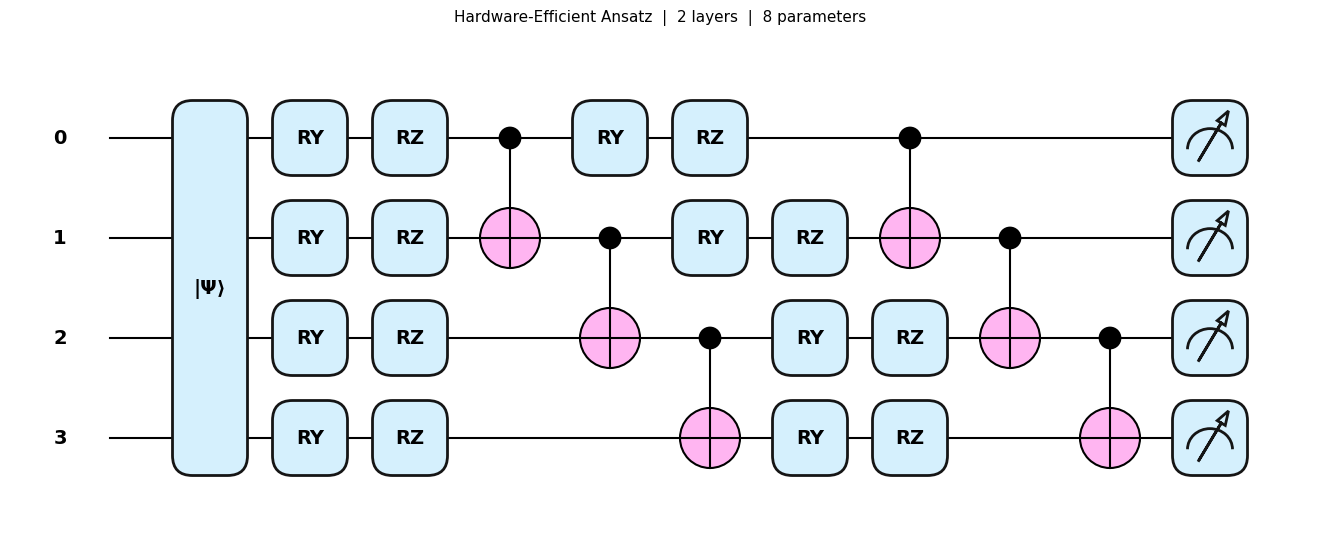

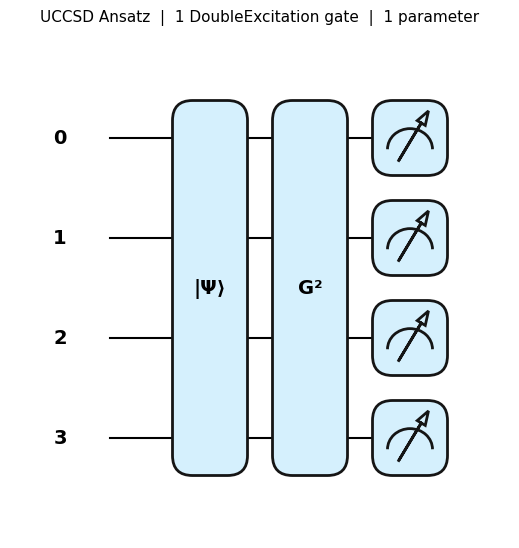

HEA parameter count: 8
UCCSD parameter count: 1


In [8]:
test_hea_params = _np.zeros((2, n_qubits, 2))   # layers, qubits, rotations
test_uccsd_params = _np.array([0.0])

# HEA circuit draw
fig_hea, ax_hea = qml.draw_mpl(hea_circuit, style="pennylane")(test_hea_params)
ax_hea.set_title(
    f"Hardware-Efficient Ansatz  |  2 layers  |  {2 * n_qubits} parameters",
    fontsize=11, pad=12
)
plt.tight_layout()
plt.show()

# UCCSD circuit draw
fig_uccsd, ax_uccsd = qml.draw_mpl(uccsd_circuit, style="pennylane")(test_uccsd_params)
ax_uccsd.set_title(
    "UCCSD Ansatz  |  1 DoubleExcitation gate  |  1 parameter",
    fontsize=11, pad=12
)
plt.tight_layout()
plt.show()

hea_n_params   = 2 * n_qubits
uccsd_n_params = 1

print(f"HEA parameter count: {hea_n_params}")
print(f"UCCSD parameter count: {uccsd_n_params}")


### Exercise 1:
Let us prepare our VQE cost function for H₂ molecule using the UCCSD ansatz. The steps are:
1.  Prepare the Hartree-Fock reference state $|1100\rangle$.
2. Apply the single UCCSD `DoubleExcitation`.

The reference state becomes $|1100\rangle \rightarrow \cos\left(\frac{\theta}{2}\right)|1100\rangle + \sin\left(\frac{\theta}{2}\right)|0011\rangle$ when we apply double excitation UCCSD ansatz.

In [9]:
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def cost_fn(params):
    ######## WRITE YOUR CODE HERE #########

    ######################################
    return qml.expval(H)

# Check if energies match and cost function is correct
E_at_zero = float(cost_fn(np.array([0.0])))
print(f"cost_fn(θ=0):{E_at_zero:.8f} Ha")
print(f"E_hf:{E_hf:.8f} Ha")
print(f"Difference (should be ~0):{abs(E_at_zero - E_hf):.2e}")
assert abs(E_at_zero - E_hf) < 1e-6, "HF energies do not match."
print(f"\nCost function is correctly defined.")

cost_fn(θ=0):-1.11663277 Ha
E_hf:-1.11663277 Ha
Difference (should be ~0):0.00e+00

Cost function is correctly defined.


### Exercise 2:

Use UCCSD ansatz from above and visualize the energy landscape for H₂ molecule.

- First, you will need to call the cost function above with the current theta value. We then append the result in the given empty list.

- Next, you will need to find the paramter theta at which the energy is minimized.

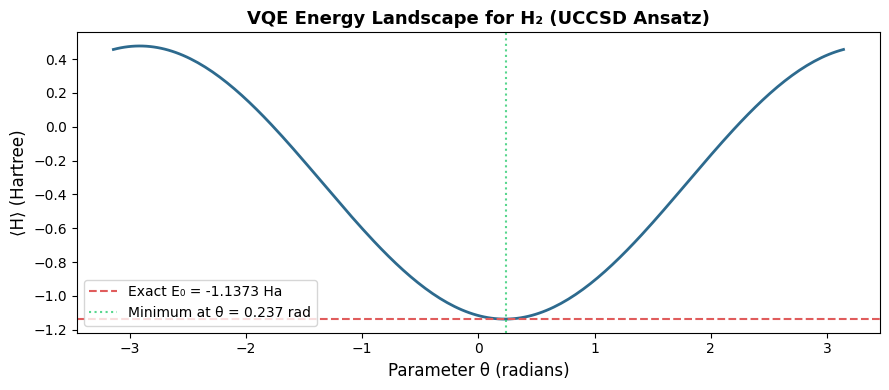

Energy minimum from sweep:-1.13721660 Ha
Exact ground state energy:-1.13725933 Ha
Difference:0.0427 mHa


In [10]:
theta_values = np.linspace(-np.pi, np.pi, 200)
energies_sweep = []

for theta in theta_values:
    # E = ######## YOUR CODE HERE ###########

    ##################################
    energies_sweep.append(E)

# theta_min = theta_values[######## YOUR CODE HERE ##############]
theta_min = theta_values[np.argmin(energies_sweep)]
E_min = min(energies_sweep)



# Plot the energy graph
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(theta_values, energies_sweep, color="#2d6a8e", linewidth=2)
ax.axhline(E_exact, linestyle="--", color="#e05c5c", label=f"Exact E₀ = {E_exact:.4f} Ha")
ax.axvline(theta_min, linestyle=":", color="#2ecc71", alpha=0.8, label=f"Minimum at θ = {theta_min:.3f} rad")
ax.set_xlabel("Parameter θ (radians)", fontsize=12)
ax.set_ylabel("⟨H⟩ (Hartree)", fontsize=12)
ax.set_title("VQE Energy Landscape for H₂ (UCCSD Ansatz)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Energy minimum from sweep:{E_min:.8f} Ha")
print(f"Exact ground state energy:{E_exact:.8f} Ha")
print(f"Difference:{abs(E_min - E_exact)*1000:.4f} mHa")

### Exercise 3:

Now that we have obtained the energy values from our parametrised circuit, we move to the
Implement the optimization loop using GradientDescentOptimizer.

Peform an optimisation step using the `GradientDescentOptimizer` class. Call the `step_and_cost` method over the defined optimizer instance `opt` and take in the previously obtained cost function and parameters to generate new parameter and energy values.

Add-ons:
- maybe add some more optimizers too - compare approaches like this standard gradient descent and "Quantum natural gradient descent"
- visualise optimisation steps to cost function value
- visualise optimisation path in the parameter space using a contour plot
- Additional reference: [tutorial on quantum natural gradients](https://pennylane.ai/qml/demos/tutorial_vqe_qng)


In [11]:
opt = qml.GradientDescentOptimizer(stepsize=0.4)
params = np.array([0.01])
energy_history = []
param_history = []

n_steps = 80

for step in range(n_steps):
    ######### YOUR CODE HERE ############

    ####################################

    energy_history.append(float(energy))
    param_history.append(float(params[0]))

    if step % 10 == 0:
        print(f"Step {step:3d} | θ = {float(params[0]):.5f} rad | E = {energy:.8f} Ha")

print(f"\nFinal energy: {energy_history[-1]:.8f} Ha")
print(f"Exact energy: {E_exact:.8f} Ha")

Step   0 | θ = 0.07939 rad | E = -1.11840681 Ha
Step  10 | θ = 0.22353 rad | E = -1.13725148 Ha
Step  20 | θ = 0.22646 rad | E = -1.13725933 Ha
Step  30 | θ = 0.22651 rad | E = -1.13725933 Ha
Step  40 | θ = 0.22652 rad | E = -1.13725933 Ha
Step  50 | θ = 0.22652 rad | E = -1.13725933 Ha
Step  60 | θ = 0.22652 rad | E = -1.13725933 Ha
Step  70 | θ = 0.22652 rad | E = -1.13725933 Ha

Final energy: -1.13725933 Ha
Exact energy: -1.13725933 Ha


Let's verify the ansatz output run and compare the VQE results with the baseline. We create an energy convergence and parameter convergence plot to visualise the effect of our VQE algorithm run to see how it gets closer to the ground state across the solution space with each iteration.

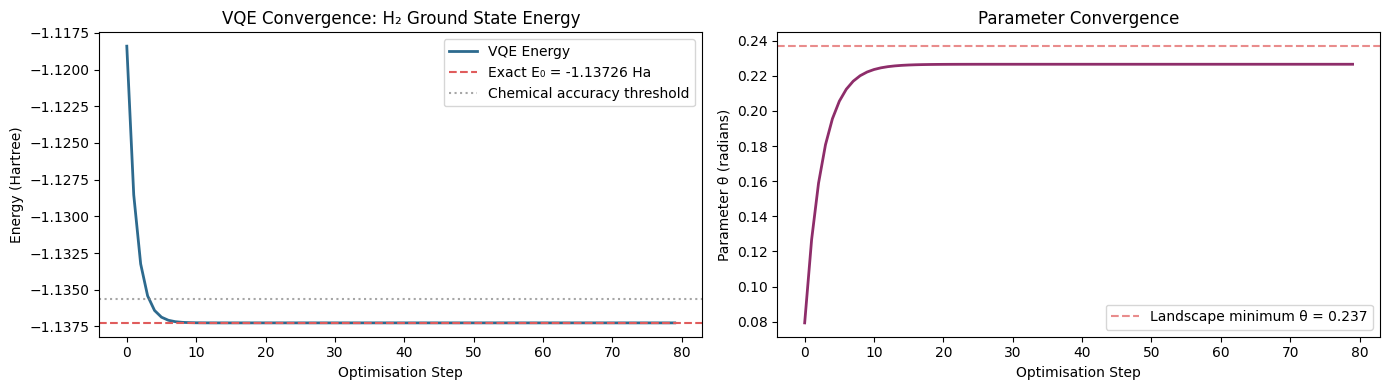

VQE ground state energy:-1.13725933 Ha
Exact ground state energy:-1.13725933 Ha
Absolute error:0.0000 mHa


In [12]:
chemical_accuracy = 0.0016  # in Hartree (1 kcal/mol is roughly equal to 1.6 mHa)
final_energy = energy_history[-1]
error = abs(final_energy - E_exact)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Energy convergence
axes[0].plot(energy_history, color="#2d6a8e", linewidth=2, label="VQE Energy")
axes[0].axhline(E_exact, linestyle="--", color="#e05c5c", linewidth=1.5, label=f"Exact E₀ = {E_exact:.5f} Ha")
axes[0].axhline(E_exact + chemical_accuracy, linestyle=":", color="grey", alpha=0.7, label="Chemical accuracy threshold")
axes[0].set_xlabel("Optimisation Step")
axes[0].set_ylabel("Energy (Hartree)")
axes[0].set_title("VQE Convergence: H₂ Ground State Energy")
axes[0].legend()

# Parameter convergence
axes[1].plot(param_history, color="#8e2d6a", linewidth=2)
axes[1].axhline(theta_min, linestyle="--", color="#e05c5c", alpha=0.7, label=f"Landscape minimum θ = {theta_min:.3f}")
axes[1].set_xlabel("Optimisation Step")
axes[1].set_ylabel("Parameter θ (radians)")
axes[1].set_title("Parameter Convergence")
axes[1].legend()

plt.tight_layout()
plt.show()

# Result summary (success if error < chemical accuracy (mHa))
print(f"VQE ground state energy:{final_energy:.8f} Ha")
print(f"Exact ground state energy:{E_exact:.8f} Ha")
print(f"Absolute error:{error*1000:.4f} mHa")

#### Other points to talk about:

Noise, noise models, ideal vs noisy energy,
ZNE (suggest to check out mitiq toolkit)

### Known limitations and open-questions:

- Barren plateaus
(Discussion,
Figures,
maybe small implementation)



### Other implementations:

- ADAPT-VQE
- QAOA

### Next steps

Change parameter values, try different functions, different optimizers and ansätze, apply different noise models, different molecules (LiH, Heisenberg Chain), see how results vary. Check for barren plateaus for higher qubit experiments. Try similar experiments with other tools (e.g. Qiskit).

#### Challenge:

Aim to apply this algorithm implementation to an application of your choice or your research domain. For the group of attendees here, applications such as machine learning, portfolio optimization, molecular simulation and energy estimation might be of interest. You may start by constructing a Hamiltonian for your problem by expressing it as a sum of Pauli tensor products, then by running VQE on the smallest non-trivial instance, and making some observations about the observable, ground/excited states, and comparing with the standard classical method.

#### Open-ended research directions:
- Barren plateaus and classical simulability
- Early fault-tolerant VQE
- ADAPT-VQE at scale ~$\mathcal{O}(100)$
- Excited-state methods
- among others...


### References and recommended reading list:

Main VQE paper
- Peruzzo, A., McClean, J., Shadbolt, P. et al. A variational eigenvalue solver on a photonic quantum processor. Nat Commun 5, 4213 (2014). https://doi.org/10.1038/ncomms5213

H₂ and other molecule implementations
- Kandala, A., Mezzacapo, A., Temme, K. et al. Hardware-efficient variational quantum eigensolver for small molecules and quantum magnets. Nature 549, 242–246 (2017). https://doi.org/10.1038/nature23879
- [PennyLane Tutorial: A brief overview of VQE](https://pennylane.ai/qml/demos/tutorial_vqe)

VQA review
- Tilly, J., Chen, H., Cao, S. et al. The variational quantum eigensolver: a review of methods and best practices. Physics Reports, 986, 1-128 (2022). https://doi.org/10.48550/arXiv.2111.05176
- Cerezo, M., Arrasmith, A., Babbush, R. et al. Variational quantum algorithms. Nat Rev Phys 3, 625–644 (2021). https://doi.org/10.1038/s42254-021-00348-9
- McClean, J. R., Romero, J., Babbush, R., and Aspuru-Guzik, A., The theory of variational hybrid quantum-classical algorithms, New J. Phys. 18 023023 (2016). https://doi.org/10.1088/1367-2630/18/2/023023

Barren plateaus
- McClean, J.R. et al. Barren plateaus in quantum neural network training landscapes. Nature Communications 9, 4812 (2018). https://doi.org/10.1038/s41467-018-07090-4

ADAPT-VQE
- Grimsley, H.R. et al. An adaptive variational algorithm for exact molecular simulations on a quantum computer. Nature Communications 10, 3007 (2019). https://doi.org/10.1038/s41467-019-10988-2
- [PennyLane Tutorial](https://pennylane.ai/qml/demos/tutorial_adaptive_circuits)

Fault-tolerant and future directions
- Wang. Z. et al. A Review of Variational Quantum Algorithms: Insights into Fault-Tolerant Quantum Computing. arXiv preprint arXiv:2604.07909 [quant-ph] (2026). https://doi.org/10.48550/arXiv.2604.07909